# 🚗 DoorDash Delivery Prediction
## Notebook 05 — Insights & Storytelling

**Goal:** Turn model results into clear business insights. This is your portfolio showcase notebook.

**Target:** `total_delivery_duration_mins` — predicted delivery time in minutes

**Author:** Divyargarg

---

In [9]:
# ── CELL 1: Import Libraries ──────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid')
print('✅ Libraries loaded!')

✅ Libraries loaded!


In [11]:
# ── CELL 2: Load Data & Model ─────────────────────────────────────────
df_features   = pd.read_csv('../data/features/features_data.csv')
test_preds    = pd.read_csv('../outputs/models/test_predictions_v2.csv')

with open('../outputs/models/best_model_v2.pkl', 'rb') as f:
    model = pickle.load(f)

print(f'✅ Features   : {df_features.shape}')
print(f'✅ Predictions: {test_preds.shape}')
print(f'✅ Model      : {type(model).__name__}')

✅ Features   : (197283, 16)
✅ Predictions: (29593, 2)
✅ Model      : XGBRegressor


## 📊 Section 1 — Project Summary

In [12]:
# ── CELL 3: Project Summary Card ─────────────────────────────────────
TARGET = 'total_delivery_duration_mins'

mae  = mean_absolute_error(test_preds['actual'], test_preds['predicted'])
rmse = np.sqrt(mean_squared_error(test_preds['actual'], test_preds['predicted']))
r2   = r2_score(test_preds['actual'], test_preds['predicted'])

print('=' * 58)
print('      DOORDASH DELIVERY PREDICTION — SUMMARY')
print('=' * 58)
print(f'  Dataset         : StrataScratch — historical_data.csv')
print(f'  Total Records   : {len(df_features):,}')
print(f'  Features Used   : {df_features.shape[1] - 1}')
print(f'  Target Variable : total_delivery_duration_mins')
print(f'  Problem Type    : Regression')
print(f'  Best Model      : {type(model).__name__}')
print()
print(f'  ┌──────────────────┬──────────────┐')
print(f'  │ Metric           │ Score        │')
print(f'  ├──────────────────┼──────────────┤')
print(f'  │ MAE              │ {mae:.2f} mins  │')
print(f'  │ RMSE             │ {rmse:.2f} mins  │')
print(f'  │ R²               │ {r2:.4f}       │')
print(f'  └──────────────────┴──────────────┘')
print()
print(f'  💡 On average the model predicts delivery time')
print(f'     within {mae:.1f} minutes of the actual time.')
print('=' * 58)

      DOORDASH DELIVERY PREDICTION — SUMMARY
  Dataset         : StrataScratch — historical_data.csv
  Total Records   : 197,283
  Features Used   : 15
  Target Variable : total_delivery_duration_mins
  Problem Type    : Regression
  Best Model      : XGBRegressor

  ┌──────────────────┬──────────────┐
  │ Metric           │ Score        │
  ├──────────────────┼──────────────┤
  │ MAE              │ 11.31 mins  │
  │ RMSE             │ 15.26 mins  │
  │ R²               │ 0.2705       │
  └──────────────────┴──────────────┘

  💡 On average the model predicts delivery time
     within 11.3 minutes of the actual time.


## 📊 Section 2 — Business Insights

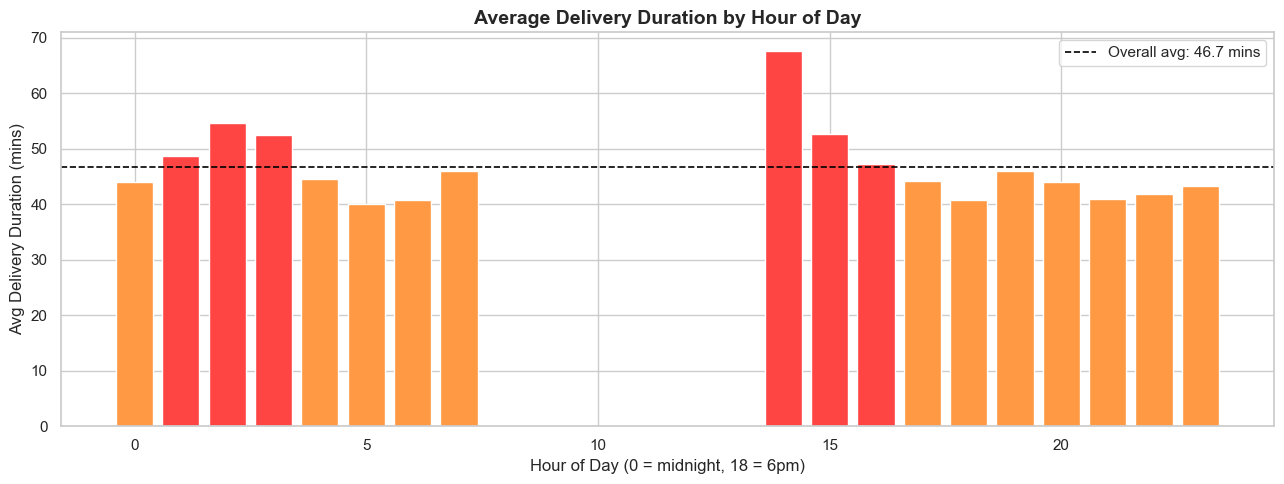


💡 INSIGHT: Slowest hour is 14:00 → avg 67.6 mins
💡 INSIGHT: Fastest hour is 5:00 → avg 40.0 mins


In [13]:
# ── CELL 4: Average Delivery Time by Hour of Day ──────────────────────
if 'order_hour' in df_features.columns:
    hour_avg = df_features.groupby('order_hour')[TARGET].mean()

    plt.figure(figsize=(13, 5))
    bars = plt.bar(hour_avg.index, hour_avg.values,
                   color=['#FF4444' if v > hour_avg.mean() else '#FF9944' for v in hour_avg.values],
                   edgecolor='white')
    plt.axhline(hour_avg.mean(), color='black', linestyle='--', linewidth=1.2,
                label=f'Overall avg: {hour_avg.mean():.1f} mins')
    plt.title('Average Delivery Duration by Hour of Day', fontsize=14, fontweight='bold')
    plt.xlabel('Hour of Day (0 = midnight, 18 = 6pm)')
    plt.ylabel('Avg Delivery Duration (mins)')
    plt.legend()
    plt.tight_layout()
    plt.savefig('../outputs/figures/05_duration_by_hour.png', dpi=150)
    plt.show()

    worst_hour = hour_avg.idxmax()
    best_hour  = hour_avg.idxmin()
    print(f'\n💡 INSIGHT: Slowest hour is {worst_hour}:00 → avg {hour_avg.max():.1f} mins')
    print(f'💡 INSIGHT: Fastest hour is {best_hour}:00 → avg {hour_avg.min():.1f} mins')

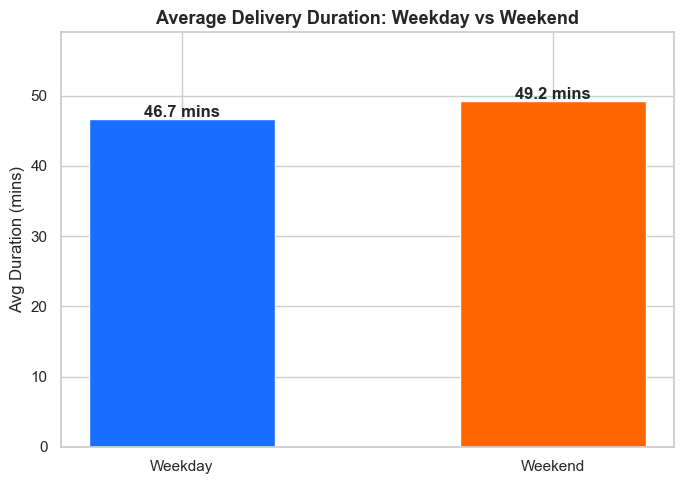


💡 INSIGHT: Weekend deliveries take 2.5 mins longer than weekdays


In [15]:
# ── CELL 5: Weekday vs Weekend Delivery Time ──────────────────────────
if 'is_weekend' in df_features.columns:
    weekend_avg = df_features.groupby('is_weekend')[TARGET].mean()

    labels = ['Weekday', 'Weekend']
    values = [weekend_avg.get(0, 0), weekend_avg.get(1, 0)]

    plt.figure(figsize=(7, 5))
    bars = plt.bar(labels, values, color=['#1a6eff', '#FF6600'], edgecolor='white', width=0.5)
    for bar, val in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f} mins', ha='center', fontweight='bold', fontsize=12)
    plt.title('Average Delivery Duration: Weekday vs Weekend', fontsize=13, fontweight='bold')
    plt.ylabel('Avg Duration (mins)')
    plt.ylim(0, max(values) * 1.2)
    plt.tight_layout()
    plt.savefig('../outputs/figures/05_weekend_vs_weekday.png', dpi=150)
    plt.show()

    diff = values[1] - values[0]
    print(f'\n💡 INSIGHT: Weekend deliveries take {abs(diff):.1f} mins {"longer" if diff > 0 else "shorter"} than weekdays')

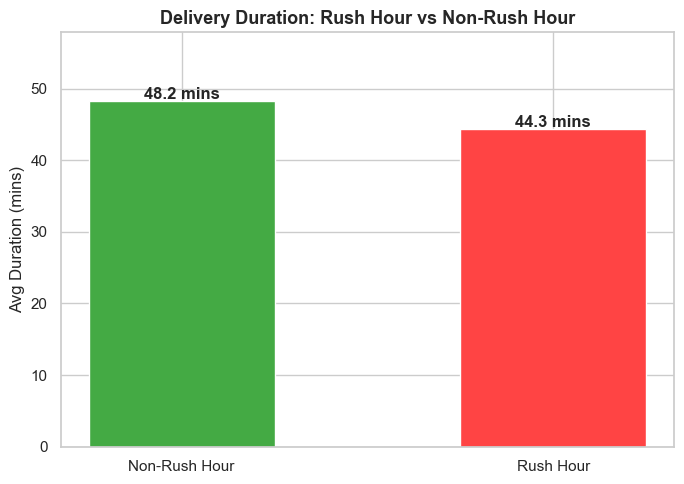


💡 INSIGHT: Rush hour adds 3.9 minutes to average delivery time


In [14]:
# ── CELL 6: Rush Hour Impact ──────────────────────────────────────────
if 'is_rush_hour' in df_features.columns:
    rush_avg = df_features.groupby('is_rush_hour')[TARGET].mean()

    labels = ['Non-Rush Hour', 'Rush Hour']
    values = [rush_avg.get(0, 0), rush_avg.get(1, 0)]

    plt.figure(figsize=(7, 5))
    bars = plt.bar(labels, values, color=['#44AA44', '#FF4444'], edgecolor='white', width=0.5)
    for bar, val in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f} mins', ha='center', fontweight='bold', fontsize=12)
    plt.title('Delivery Duration: Rush Hour vs Non-Rush Hour', fontsize=13, fontweight='bold')
    plt.ylabel('Avg Duration (mins)')
    plt.ylim(0, max(values) * 1.2)
    plt.tight_layout()
    plt.savefig('../outputs/figures/05_rush_hour.png', dpi=150)
    plt.show()

    diff = values[1] - values[0]
    print(f'\n💡 INSIGHT: Rush hour adds {abs(diff):.1f} minutes to average delivery time')

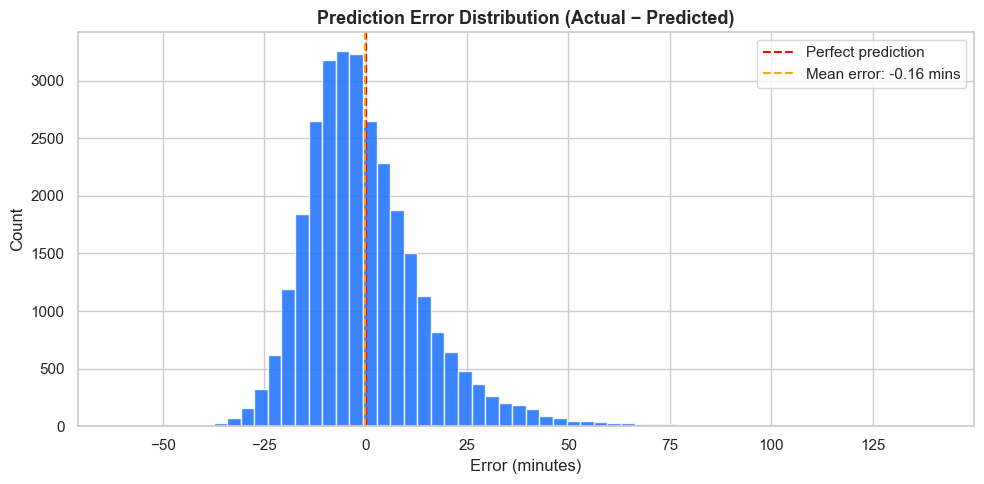


💡 28.5% of predictions are within 5 minutes of actual
💡 54.8% of predictions are within 10 minutes of actual


In [17]:
# ── CELL 8: Prediction Error Distribution ────────────────────────────
errors = test_preds['actual'] - test_preds['predicted']

plt.figure(figsize=(10, 5))
plt.hist(errors, bins=60, color='#1a6eff', edgecolor='white', alpha=0.85)
plt.axvline(0, color='red', linestyle='--', linewidth=1.5, label='Perfect prediction')
plt.axvline(errors.mean(), color='orange', linestyle='--', linewidth=1.5,
            label=f'Mean error: {errors.mean():.2f} mins')
plt.title('Prediction Error Distribution (Actual − Predicted)', fontsize=13, fontweight='bold')
plt.xlabel('Error (minutes)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/figures/05_error_distribution.png', dpi=150)
plt.show()

within_5  = (errors.abs() <= 5).mean() * 100
within_10 = (errors.abs() <= 10).mean() * 100
print(f'\n💡 {within_5:.1f}% of predictions are within 5 minutes of actual')
print(f'💡 {within_10:.1f}% of predictions are within 10 minutes of actual')